## Breast Cancer Detection System 


Import Library  for this project

In [38]:
import pandas as pd
import numpy as np

In [39]:
import matplotlib.pyplot as plt


Upload a dataset 

In [40]:
breast= pd.read_csv('Breast Cancer.csv')
breast.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [41]:
breast['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

M stand for maglignant 
B stand for benign
 any person they have breast cancer that show maglignant

Asq six Questions about this dataset

In [42]:
breast.shape

(569, 33)

In [43]:
breast.isnull().sum()


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [44]:
breast.duplicated().sum()

0

In [45]:
breast.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [46]:
breast.drop('Unnamed: 32', axis=1, inplace=True)

In [47]:
breast.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [48]:
breast.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Encoding

In [49]:
#from sklearn.preprocessing import LabelEncoder
#le=LabelEncoder()

In [50]:
breast['diagnosis'] = breast['diagnosis'].map({"M": 1, "B": 0})

In [51]:
breast['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

Splitting Data into Traning and Testing sets

In [52]:
X =breast.drop('diagnosis',axis=1)
Y = breast['diagnosis']

In [53]:
X.shape

(569, 31)

In [54]:
Y.shape

(569,)

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [57]:
X_train.shape

(455, 31)

In [58]:
X_test.shape

(114, 31)

Feature Scaling

In [59]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [60]:
sc.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [61]:
X_train =sc.transform(X_train)
X_test = sc.transform(X_test)

In [62]:
X_train

array([[-0.23712699, -1.44075296, -0.43531947, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [-0.23702031,  1.97409619,  1.73302577, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-0.23712907, -1.39998202, -1.24962228, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [-0.17630431,  0.04880192, -0.55500086, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.23675669, -0.03896885,  0.10207345, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.2371006 , -0.54860557,  0.31327591, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

Model train and Selection  

Train LogisticRegression 

In [ ]:
from sklearn.linear_model import LogisticRegression
lg_model = LogisticRegression()

lg_model.fit(X_train, Y_train)

lg_pred = lg_model.predict(X_test)

Train RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

Train SVM

In [ ]:
from sklearn.svm import SVC
svm_model = SVC()

svm_model.fit(X_train, Y_train)

svm_pred = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:",
      accuracy_score(Y_test, lg_pred))

print("Random Forest Accuracy:",
      accuracy_score(Y_test, rf_pred))

print("SVM Accuracy:",
      accuracy_score(Y_test, svm_pred))

Logistic Regression Accuracy: 0.9736842105263158
Random Forest Accuracy: 0.9649122807017544
SVM Accuracy: 0.9824561403508771


In [ ]:
from sklearn.metrics import classification_report

print("SVM Report")
print(classification_report(Y_test, svm_pred))

SVM Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Add Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, svm_pred)

print(cm)

[[71  0]
 [ 2 41]]


Visuilization 

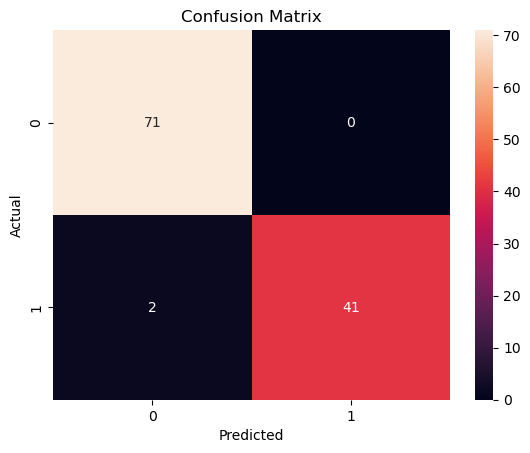

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Preditction System 

In [ ]:
input_text =(-0.23687964,  0.04030797, -0.23819718, -0.02725804, -0.06001243,
       -2.15592988, -0.98104496, -0.80810952, -0.90850515, -0.64095228,
       -0.95764719, -0.60815306, -0.9862056 , -0.57868202, -0.4135118 ,
       -1.25105866, -0.63839765, -0.68618822, -1.05785631, -1.16912304,
       -0.66932816, -0.00314261, -0.0455055 , -0.03908819, -0.10102666,
       -1.6082721 , -0.23276225, -0.56459233, -0.59585724, -0.42646531,
       -0.39868387)
np_df = np.asarray(input_text)
predection = lg_model.predict(np_df.reshape(1,-1))

if predection[0] ==1:
    print("Cancer Detected")
else:
    print("No Cancer Detected")

No Cancer Detected


In [ ]:
X_train[19]

array([-0.23686779, -0.6845087 , -0.01760794, -0.72245467, -0.66471764,
       -0.54674914, -0.97474879, -0.92047967, -0.96795012,  0.45530393,
       -0.205056  , -0.8552809 ,  0.42005448, -0.84548643, -0.61018705,
       -0.30295814, -0.88912   , -0.69771103, -0.67692285,  0.35728285,
       -0.77564737, -0.75429058,  0.16742062, -0.78538441, -0.69462649,
       -0.40040255, -0.93023911, -0.93439101, -0.87001559,  0.92257681,
       -0.80141491])

In [ ]:
print(X_train.shape)

(455, 31)


In [ ]:
import pickle
pickle.dump(lg_model, open('model.pkl', 'wb'))
pickle.dump(sc, open('scaler.pkl', 'wb'))